# Contents

Generates new synthetic faces, by sampling from the latent space of the VanillaVAE trained on the degraded images.

z ~ N(0,I) -> decode(z) produces directly a face 128x128 with the maximum degradation, no processing is needed after that.

## imports and loadings

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
import torch
from PIL import Image

from matplotlib import pyplot as plt

In [3]:
# CONFIG
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" \
    if 'google.colab' in str(get_ipython()) else "."

PYTORCH_VAE_REPO = os.path.join(BASE_DIR, 'src/PyTorch-VAE-master')
CHECKPOINT_PATH  = os.path.join(BASE_DIR, 'trained_models', 'vae',
                                'vae_blur_checkpoint_128x128.pt')
OUTPUT_DIR = os.path.join(BASE_DIR, 'data', 'generated_images1')

NUM_SAMPLES  = 1000
BATCH_SIZE   = 32
TEMPERATURE  = 1.4   # >1 = more diversity in faces, <1 = less st dev
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
sys.path.append(PYTORCH_VAE_REPO)
from models.vanilla_vae import VanillaVAE


def load_vae(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = VanillaVAE(
        in_channels=3,
        latent_dim=ckpt['latent_dim'],
        hidden_dims=list(ckpt['hidden_dims']),
    ).to(device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    print(f"VAE loaded from step {ckpt.get('step','?')}, "
          f"latent_dim={ckpt['latent_dim']}, patch_size={ckpt.get('patch_size','?')}")
    return model

## generation

In [5]:
def vae_generate(num_samples, vae, device, temperature=1.0):
    """
    z ~ N(0, temperature^2 * I) -> decode(z).
    Output: [0,1] float32 clamped, shape [num_samples, 3, 128, 128].
    Already 128x128: VAE is trained on this resolution.
    """
    z = torch.randn(num_samples, vae.latent_dim, device=device) * temperature
    with torch.no_grad():
        samples = vae.decode(z)
    return samples.clamp(0.0, 1.0)


def generate_dataset():
    vae = load_vae(CHECKPOINT_PATH, DEVICE)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    generated = 0
    idx = 0
    while generated < NUM_SAMPLES:
        n = min(BATCH_SIZE, NUM_SAMPLES - generated)
        samples = vae_generate(n, vae, DEVICE, temperature=TEMPERATURE)
        # [0,1] -> uint8, once for each batch
        samples_u8 = (samples * 255.0).round().clamp(0, 255).byte().cpu()

        for i in range(n):
            arr = samples_u8[i].permute(1, 2, 0).numpy()
            Image.fromarray(arr).save(os.path.join(OUTPUT_DIR, f"vae_face_{idx:06d}.jpg"))
            idx += 1

        generated += n
        print(f"{generated}/{NUM_SAMPLES} volti generati")

    print(f"Fatto. {NUM_SAMPLES} volti sintetici in {OUTPUT_DIR}")

In [6]:
generate_dataset()

VAE loaded from step 6332, latent_dim=128, patch_size=128
32/1000 volti generati
64/1000 volti generati
96/1000 volti generati
128/1000 volti generati
160/1000 volti generati
192/1000 volti generati
224/1000 volti generati
256/1000 volti generati
288/1000 volti generati
320/1000 volti generati
352/1000 volti generati
384/1000 volti generati
416/1000 volti generati
448/1000 volti generati
480/1000 volti generati
512/1000 volti generati
544/1000 volti generati
576/1000 volti generati
608/1000 volti generati
640/1000 volti generati
672/1000 volti generati
704/1000 volti generati
736/1000 volti generati
768/1000 volti generati
800/1000 volti generati
832/1000 volti generati
864/1000 volti generati
896/1000 volti generati
928/1000 volti generati
960/1000 volti generati
992/1000 volti generati
1000/1000 volti generati
Fatto. 1000 volti sintetici in /content/drive/MyDrive/Colab Notebooks/tesi/data/generated_images1


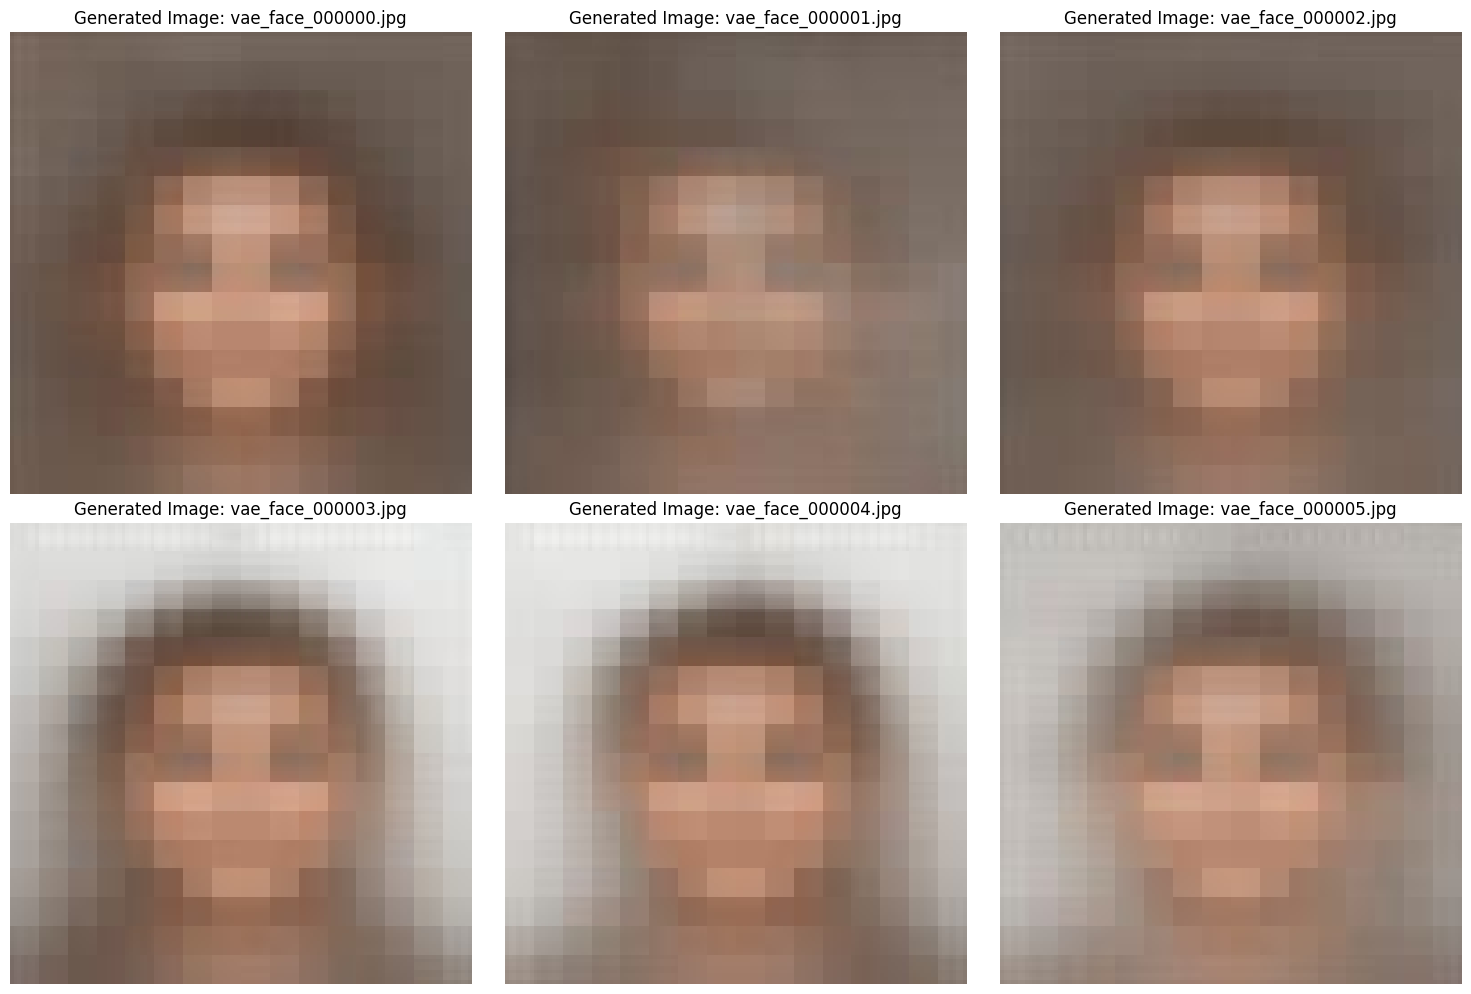

In [7]:
# Get a list of all files in the output directory
image_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(('.jpg', '.png'))]
image_files.sort() # Ensure consistent order

if image_files:
    num_images_to_plot = min(6, len(image_files))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # Create a 2x3 grid for up to 6 images
    axes = axes.flatten() # Flatten the 2x3 array of axes for easier iteration

    for i in range(num_images_to_plot):
        image_name = image_files[i]
        current_image_path = os.path.join(OUTPUT_DIR, image_name)

        # Load the image
        img = Image.open(current_image_path)

        # Plot the image on the current subplot
        axes[i].imshow(img)
        axes[i].set_title(f"Generated Image: {image_name}")
        axes[i].axis('off') # Hide axes ticks and labels

    # Turn off any unused subplots
    for j in range(num_images_to_plot, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.show()
else:
    print(f"No images found in {OUTPUT_DIR}. Please run generate_dataset() first.")